# Task 1

In [194]:
import pandas as pd

cars_df = pd.read_csv("cars.csv")

In [195]:
cars_df.loc[344]

mpg                       39.0
cylinders                    4
displacement              86.0
horsepower                  64
weight                    1875
acceleration              16.4
model year                  81
origin                       1
car name        plymouth champ
Name: 344, dtype: object

1. Horsepower was the wrong type and origin is suppose to be categories.

# Task 2

In [196]:
cars_df["horsepower"] = pd.to_numeric(cars_df["horsepower"], errors="coerce")
cars_df = cars_df.dropna()
cars_df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

# Task 3

In [197]:
X = cars_df.drop(columns=["car name", "mpg"])
y = cars_df["mpg"]

#It cannot be used as model input because it is not numeric

# Task 4

1. We are leaking the test data into the training data. Our model will give inaccurate data.

In [198]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)


#  Task 5

In [199]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False)

origin_encode = ohe.fit_transform(X_train[["origin"]])
test_encode = ohe.transform(X_test[['origin']])
origin_cols = ohe.get_feature_names_out(['origin'])

origin_df = pd.DataFrame(origin_encode, columns=origin_cols, dtype=int)
X_train = pd.concat([X_train.drop(columns=['origin']).reset_index(), origin_df], axis=1)

In [200]:
X_train

,index,cylinders,displacement,horsepower,weight,acceleration,model year,origin_1,origin_2,origin_3
0,260,6,225.0,110.0,3620,18.7,78,1,0,0
1,184,4,140.0,92.0,2572,14.9,76,1,0,0
2,174,6,171.0,97.0,2984,14.5,75,1,0,0
3,64,8,318.0,150.0,4135,13.5,72,1,0,0
4,344,4,86.0,64.0,1875,16.4,81,1,0,0
...,...,...,...,...,...,...,...,...,...,...
308,72,8,304.0,150.0,3892,12.5,72,1,0,0
309,107,6,232.0,100.0,2789,15.0,73,1,0,0
310,272,4,151.0,85.0,2855,17.6,78,1,0,0
311,352,4,98.0,65.0,2380,20.7,81,1,0,0


In [201]:
test_df = pd.DataFrame(test_encode, columns=origin_cols, dtype=int)
X_test = pd.concat([X_test.drop(columns=['origin']), test_df], axis=1)

# Task 6

1. We are dropping origin_3. It does not matter because if its not 1 or 2 it has to be 3 and the same for all 3. 
2. It's different because this is perfectly multicollinear. We can tell the value of the third column based on the first 2.

In [202]:
X_train = X_train.drop(columns=['origin_3'])
X_test = X_test.drop(columns=['origin_3'])

# Task 7

In [211]:
from sklearn.preprocessing import StandardScaler


ss = StandardScaler()
X_train[['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year']] = ss.fit_transform(X_train[['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year']])
X_test[['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year']] = ss.transform(X_test[['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year']])
print("Mean:", X_train['cylinders'].mean())
print("STD:", X_train['cylinders'].std())
print("Test:", X_test["cylinders"].mean())




Mean: -3.4051568806394576e-17
STD: 1.0016012820504612
Test: -0.03065766700014038


# Task 8

In [208]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

numeric_cols = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year']
nominal_cols = ['origin']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('nom', OneHotEncoder(sparse_output=False), nominal_cols)
])

pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
pipe.fit(X_train, y_train)
y_prep = pipe.predict(X_test)

r2 = r2_score(y_test, y_prep)
mae = mean_absolute_error(y_test, y_prep)

print("r2 score =", r2)
print("mae =", mae)

r2 score = 0.7922774714022581
mae = 2.461999698066147


# Advanced Task 1

Text(0.5, 0, 'predicted')

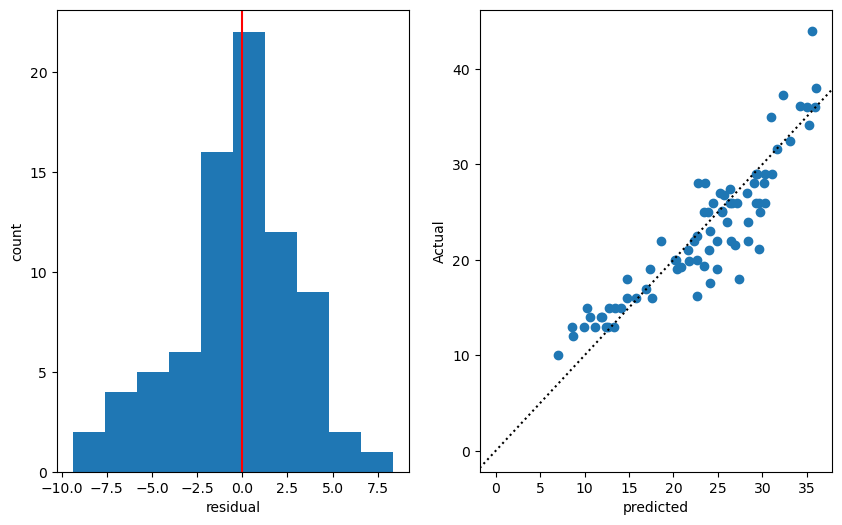

In [223]:
import matplotlib.pyplot as plt

residual = y_test - y_prep

plt.figure(figsize=(10,6))

plt.subplot(1,2,1)
plt.hist(residual)
plt.ylabel("count")
plt.xlabel("residual")
plt.axvline(0, color="Red")

plt.subplot(1,2,2)
plt.scatter(y_prep, y_test)
plt.axline((0, 0), slope=1, color='black', linestyle=':')
plt.ylabel("Actual")
plt.xlabel("predicted")


1. It is evenly spread
2. None are really far off
3. our limits were good

# Advanced task 2

In [226]:
print("Preprocessed r2 score =", r2)
print("Preprocessed mae =", mae)

X = cars_df.drop(columns=["car name", "mpg"])
y = cars_df["mpg"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Not processed r2:", model.score(X_test, y_test))
print("Not processed mae:", mean_absolute_error(y_test, y_pred))



Preprocessed r2 score = 0.7922774714022581
Preprocessed mae = 2.461999698066147
Not processed r2: 0.7901500386760352
Not processed mae: 2.419780249197449


1. Preprocessed performed better but only slightly
2. If the colum was categories then skipping encoding would hurt and if values aren't scaled it would treat every increment of 1 the same.
3. In the cars data set it if we removed model year and origin.

# Extra Credit

In [231]:
X = cars_df.drop(columns=["model year", "car name", "mpg", "origin"])
y = cars_df["mpg"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

numeric_cols = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']

preprocessor = ColumnTransformer(transformers=[
('num', StandardScaler(), numeric_cols)    
])
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

pipe['model'].coef_


array([-0.29847421, -0.69543821, -1.86939436, -4.19210419, -0.17006468])

1. VIF tells us how closly the categories corelate with each other.